In [1]:
# ----------------------------------------------------------------------
# 1. 環境設定與全域常數
# ----------------------------------------------------------------------
import glob
import warnings
from functools import lru_cache

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.unicode.east_asian_width", True)

# 6 測站座標資訊
STATIONS_INFO = {
    "HWA": {"name": "花蓮", "lat": 23.9754, "lon": 121.6133},
    "TUN": {"name": "壯圍(宜蘭)", "lat": 24.7437, "lon": 121.7896},
    "DON": {"name": "東和(雲林)", "lat": 23.6849, "lon": 120.5699},
    "LIU": {"name": "六甲(台南)", "lat": 23.2254, "lon": 120.3506},
    "NAB": {"name": "那菝(台南)", "lat": 23.0691, "lon": 120.3487},
    "CHI": {"name": "赤山(屏東)", "lat": 22.5924, "lon": 120.6144},
}

# 觀測項目設定：有效值範圍為開區間 (lo, hi)，範圍外設為 NaN
FEATURE_CFG = {
    "water_level": {
        "cols": ["WaterLevel"],
        "valid": (-9000, 9000),
        "unit": "cm",
        "name": "水位",          # 時序圖用
        "label": "地下水位",     # 統計圖用
        "stat_name": "地下水位同震波幅",
        "color": "#1f77b4",
    },
    "pressure": {
        "cols": ["Atmospheric pressure", "Atmospheric Pressure"],
        "valid": (0, 9000),
        "unit": "hPa",
        "name": "大氣壓力",
        "label": "大氣壓力",
        "stat_name": "大氣壓力波動",
        "color": "#2ca02c",
    },
    "upper_temp": {
        "cols": ["Upper Temperature", "Upper_Temperature", "Temperature"],
        "valid": (0, 80),
        "unit": "°C",
        "name": "水溫",
        "label": "上水溫",
        "stat_name": "水溫波動",
        "color": "#ff7f0e",
    },
    "bottom_temp": {
        "cols": ["Bottom Temperature", "Bottom_Temperature"],
        "valid": (0, 80),
        "unit": "°C",
        "name": "下水溫",
        "label": "下水溫",
        "stat_name": "下水溫波動",
        "color": "#d62728",
    },
}
FEATURE_CFG["air_pressure"] = FEATURE_CFG["pressure"]  # 別名相容

# 時間視窗（相對發震時間，單位：分鐘，兩端皆含）
TTEST_PRE_WIN = (-10, -2)    # 震前基準
TTEST_POST_WIN = (3, 11)     # 震後狀態
AMP_WIN = (0, 10)            # 震後動態晃動期
WINDOW_PAD_MIN = 15          # 快取視窗需涵蓋以上所有視窗

# 規模分級
MAG_THRESHOLD = 6.00
CATEGORIES = ["ML >= 7.0", "6.7 - 7.0", "6.4 - 6.7", "6.0 - 6.4"]
CAT_STYLES = {
    "ML >= 7.0": {"color": "#d62728", "marker": "*"},
    "6.7 - 7.0": {"color": "#ff7f0e", "marker": "^"},
    "6.4 - 6.7": {"color": "#1f77b4", "marker": "o"},
    "6.0 - 6.4": {"color": "#2ca02c", "marker": "s"},
}
LOG_FLOOR = 1e-3   # 對數刻度防呆底限
X_LIM = (-5, 270)

In [2]:
# ----------------------------------------------------------------------
# 2. 讀取地震目錄並顯示台灣時間前 50 大排行榜
# ----------------------------------------------------------------------
catalog_files = glob.glob("GDMScatalog*.csv")
catalog_file = (
    "GDMScatalog_3.csv" if "GDMScatalog_3.csv" in catalog_files else catalog_files[0]
)

df_catalog = pd.read_csv(catalog_file, encoding="utf-8-sig")
df_catalog.columns = df_catalog.columns.str.strip()

# 轉換時間為台灣時間 (UTC+8)
df_catalog["dt_utc"] = pd.to_datetime(
    df_catalog["date"].astype(str) + " " + df_catalog["time"].astype(str),
    errors="coerce",
)
df_catalog["dt_local"] = df_catalog["dt_utc"] + pd.Timedelta(hours=8)

# 依規模排序後的目錄（rank 1 = 最大），全 notebook 共用
df_sorted = df_catalog.sort_values(by="ML", ascending=False).reset_index(drop=True)
M_RANKS = list(df_sorted[df_sorted["ML"] >= MAG_THRESHOLD].index + 1)
N_EVENTS = len(M_RANKS)

df_top50 = df_sorted.head(50).copy()
df_top50.index = df_top50.index + 1
df_top50_display = pd.DataFrame(
    {
        "日期": df_top50["dt_local"].dt.strftime("%Y-%m-%d"),
        "當地時間": df_top50["dt_local"].dt.strftime("%H:%M:%S.%f").str[:-4],
        "規模(ML)": df_top50["ML"],
        "緯度(°N)": df_top50["lat"],
        "經度(°E)": df_top50["lon"],
        "深度(km)": df_top50["depth"],
    }
)

print(f"📊 地震目錄（{catalog_file}）規模前 50 大地震排行榜 (台灣時間 UTC+8)：")
print(f"   其中 ML >= {MAG_THRESHOLD:.2f} 共 {N_EVENTS} 場")
display(df_top50_display)

📊 地震目錄（GDMScatalog.csv）規模前 50 大地震排行榜 (台灣時間 UTC+8)：
   其中 ML >= 6.00 共 43 場


,日期,當地時間,規模(ML),緯度(°N),經度(°E),深度(km)
1,2024-04-03,07:58:09.94,7.19,23.8757,121.5735,19.72
2,2009-12-19,21:02:16.34,6.92,23.7880,121.6633,43.78
3,2022-09-18,14:44:15.25,6.83,23.1370,121.1958,7.81
4,2022-03-23,01:41:38.85,6.70,23.3985,121.6118,25.73
5,2022-09-17,21:41:19.11,6.60,23.0840,121.1608,8.61
6,2016-02-06,03:57:26.08,6.60,22.9220,120.5438,14.64
7,2024-04-03,08:11:26.39,6.56,24.1300,121.6513,13.44
8,2021-10-24,13:11:34.67,6.54,24.5333,121.7752,65.60
9,2022-12-15,12:03:16.42,6.51,23.7787,121.8450,16.30
10,2013-06-02,13:43:03.21,6.48,23.8615,120.9742,14.54


In [3]:
# ----------------------------------------------------------------------
# 3. 共用工具函式
# ----------------------------------------------------------------------
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    )
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))


def get_event_by_rank(rank=1):
    """讀取第 rank 大地震的發生時間、規模與各測站震央距離"""
    eq = df_sorted.iloc[rank - 1]
    dists = {
        code: haversine(eq["lat"], eq["lon"], info["lat"], info["lon"])
        for code, info in STATIONS_INFO.items()
    }
    return {
        "time": eq["dt_local"],
        "mag": eq["ML"],
        "date_str": eq["dt_local"].strftime("%Y%m%d"),
        "dists": dists,
    }


def event_label(event):
    return f"{event['time'].strftime('%Y-%m-%d')} (ML {event['mag']})"


def find_event_files(date_str, station=None):
    """找出某日期的測站觀測檔（排除 .csv / .ipynb）"""
    pattern = f"*{date_str}*{station}*" if station else f"*{date_str}*"
    return sorted(
        f for f in glob.glob(pattern) if not f.lower().endswith((".csv", ".ipynb"))
    )


def station_code(file_path):
    return file_path.split(".")[1]


def station_meta(file_path, event):
    """回傳 (測站代碼, 測站名稱, 震央距離)"""
    code = station_code(file_path)
    return (
        code,
        STATIONS_INFO.get(code, {}).get("name", ""),
        event["dists"].get(code, 0.0),
    )


@lru_cache(maxsize=12)
def read_station_file(file_path):
    """讀取原始秒級觀測檔（同一天多場地震時可重用）"""
    df = pd.read_csv(file_path)
    df["Time"] = pd.to_datetime(df["Time"])
    return df


def clean_feature(df, feature):
    """依 FEATURE_CFG 清理異常值，回傳 (有效欄位名稱, 清理後 DataFrame)

    依序嘗試候選欄位名稱，選第一個全天有任何有效值的欄位；找不到則回傳 (None, df)。
    """
    cfg = FEATURE_CFG[feature]
    lo, hi = cfg["valid"]
    df = df.copy()
    for c in cfg["cols"]:
        if c in df.columns:
            df[c] = df[c].where((df[c] > lo) & (df[c] < hi))
            if df[c].notna().any():
                return c, df
    return None, df


@lru_cache(maxsize=None)
def get_event_window(file_path, feature, eq_time):
    """發震前後 WINDOW_PAD_MIN 分鐘的清理後序列（快取，供批次計算重複使用）

    回傳 DataFrame[Time, value]；該測站無有效欄位時回傳 None。
    """
    valid_col, df = clean_feature(read_station_file(file_path), feature)
    if valid_col is None:
        return None
    pad = pd.Timedelta(minutes=WINDOW_PAD_MIN)
    mask = (df["Time"] >= eq_time - pad) & (df["Time"] <= eq_time + pad)
    return df.loc[mask, ["Time", valid_col]].rename(columns={valid_col: "value"})


def slice_window(win, eq_time, start_min, end_min):
    """取 [eq_time + start_min, eq_time + end_min] 區間的有效值（兩端皆含）"""
    t0 = eq_time + pd.Timedelta(minutes=start_min)
    t1 = eq_time + pd.Timedelta(minutes=end_min)
    return win.loc[(win["Time"] >= t0) & (win["Time"] <= t1), "value"].dropna()


def categorize_mag(mag):
    if mag >= 7.0:
        return "ML >= 7.0"
    elif mag >= 6.7:
        return "6.7 - 7.0"
    elif mag >= 6.4:
        return "6.4 - 6.7"
    else:
        return "6.0 - 6.4"


def log_tick_formatter():
    """刻度小於 0.01 時以純小數 (如 0.001) 顯示"""
    return ticker.FuncFormatter(lambda y, _: f"{y:.3f}" if 0 < y < 0.01 else f"{y:g}")

In [4]:
# ----------------------------------------------------------------------
# 4. 單一事件時序圖
# ----------------------------------------------------------------------
def plot_seismic_event(
    rank=1,
    feature="water_level",
    mode="zoom",
    window_min=10,
    target_station=None,
    calc_stats=False,
):
    event = get_event_by_rank(rank)
    eq_time, eq_mag = event["time"], event["mag"]
    cfg = FEATURE_CFG[feature]

    files = find_event_files(event["date_str"], target_station)
    if not files:
        print(f"⚠️ 找不到對應 {event['date_str']} 的測站資料檔！")
        return

    if mode == "day":
        t_start = pd.to_datetime(f"{eq_time.strftime('%Y-%m-%d')} 00:00:00")
        t_end = pd.to_datetime(f"{eq_time.strftime('%Y-%m-%d')} 23:59:59")
        padding = pd.Timedelta(minutes=30)
    else:
        t_start = eq_time - pd.Timedelta(minutes=window_min)
        t_end = eq_time + pd.Timedelta(minutes=window_min)
        padding = pd.Timedelta(seconds=0)

    results = []
    fig, axes = plt.subplots(len(files), 1, figsize=(12, 2.5 * len(files)), sharex=True)
    if len(files) == 1:
        axes = [axes]

    for ax, file_path in zip(axes, files):
        st_code, st_name, dist = station_meta(file_path, event)
        valid_col, df = clean_feature(read_station_file(file_path), feature)

        sub = df[(df["Time"] >= t_start) & (df["Time"] <= t_end)]
        pre = df[(df["Time"] >= eq_time - pd.Timedelta(minutes=5)) & (df["Time"] < eq_time)]
        post_eq = sub[sub["Time"] >= eq_time]

        ax.axvline(
            eq_time, color="red", linestyle="--", linewidth=1.2,
            label=f"發震 ({eq_time.strftime('%H:%M:%S')})",
        )

        if valid_col and not sub[valid_col].dropna().empty:
            ax.plot(sub["Time"], sub[valid_col], label=f"{st_code} {cfg['name']}",
                    color=cfg["color"], linewidth=1.0)

            if calc_stats and not post_eq[valid_col].dropna().empty:
                v_pre = (
                    pre[valid_col].mean()
                    if not pre[valid_col].dropna().empty
                    else sub[valid_col].iloc[0]
                )
                v_max = post_eq[valid_col].max()
                v_min = post_eq[valid_col].min()
                u = cfg["unit"]
                results.append({
                    "測站代碼": st_code,
                    "測站名稱": st_name,
                    "距震央距離 (km)": round(dist, 1),
                    f"震前基準 ({u})": round(v_pre, 2),
                    f"最高 ({u})": round(v_max, 2),
                    f"最低 ({u})": round(v_min, 2),
                    f"最大全振幅 ({u})": round(v_max - v_min, 2),
                    "最大向上偏移": round(v_max - v_pre, 2),
                    "最大向下偏移": round(v_min - v_pre, 2),
                })
                t_max = post_eq.loc[post_eq[valid_col] == v_max, "Time"].iloc[0]
                t_min = post_eq.loc[post_eq[valid_col] == v_min, "Time"].iloc[0]
                ax.plot(t_max, v_max, "^", color="red", markersize=6, label=f"Max: {v_max:.2f}")
                ax.plot(t_min, v_min, "v", color="green", markersize=6, label=f"Min: {v_min:.2f}")

            ax.legend(loc="upper left", ncol=2, frameon=True, framealpha=0.8, fontsize=8.5)
        else:
            ax.text(0.5, 0.5, "[無有效資料]", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.legend(loc="upper left", frameon=True, framealpha=0.8, fontsize=8.5)

        ax.set_ylabel(f"{cfg['name']} ({cfg['unit']})", fontsize=10)
        ax.set_title(f"測站：{st_code} {st_name}（ 距震央 {dist:.1f} km ）",
                     loc="left", fontweight="bold")
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
        ax.grid(True, linestyle=":", alpha=0.6)

    if mode == "day":
        axes[-1].set_xlim(t_start - padding, t_end + padding)
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H"))
        plt.xlabel("時間 (小時)", fontsize=11)
        stitle = f"{eq_time.strftime('%Y-%m-%d')} 全天 24 小時 6 測站{cfg['name']}變化對應圖"
    else:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        plt.xlabel("時間 (時:分:秒)", fontsize=11)
        stitle = (f"{eq_time.strftime('%Y-%m-%d')} 強震 (ML {eq_mag}) 前後 "
                  f"{window_min} 分鐘 6 測站{cfg['name']}圖")

    plt.suptitle(stitle, y=0.995, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if calc_stats and results:
        print(f"\n================ 📊 {eq_time.strftime('%Y-%m-%d')} 強震 "
              f"{cfg['stat_name']}統計表 ================")
        display(pd.DataFrame(results).style.hide(axis="index"))

In [5]:
# ----------------------------------------------------------------------
# 5. 單一事件計算：Welch's t-test 淨位移 / 震後峰對峰震幅
# ----------------------------------------------------------------------
def _iter_station_windows(rank, feature):
    """逐測站產生 (event, 測站代碼, 名稱, 距離, 視窗序列)；rank 超出範圍或無檔案時不產生"""
    try:
        event = get_event_by_rank(rank)
    except Exception:
        return
    for file_path in find_event_files(event["date_str"]):
        win = get_event_window(file_path, feature, event["time"])
        if win is None:
            continue
        st_code, st_name, dist = station_meta(file_path, event)
        yield event, st_code, st_name, dist, win


def _significance(p_val, mean_diff):
    if p_val < 0.001:
        level = "*** (極顯著)"
    elif p_val < 0.01:
        level = "** (高度顯著)"
    elif p_val < 0.05:
        level = "* (顯著)"
    else:
        level = "不顯著"
    if p_val < 0.05:
        response = "🟢 顯著上升" if mean_diff > 0 else "🔴 顯著下降"
    else:
        response = "⚪ 無顯著變化"
    return level, response


def calc_event_ttest(rank=1, feature="water_level"):
    """各測站震前 vs. 震後 Welch's t-test 與淨位移"""
    unit = FEATURE_CFG[feature]["unit"]
    records = []
    for event, st_code, st_name, dist, win in _iter_station_windows(rank, feature):
        eq_time = event["time"]
        pre_seq = slice_window(win, eq_time, *TTEST_PRE_WIN)
        post_seq = slice_window(win, eq_time, *TTEST_POST_WIN)
        if len(pre_seq) < 5 or len(post_seq) < 5:
            continue

        pre_mean, post_mean = pre_seq.mean(), post_seq.mean()
        mean_diff = post_mean - pre_mean

        if pre_seq.std() < 1e-6 and post_seq.std() < 1e-6:
            if abs(mean_diff) < 1e-4:
                t_stat, p_val = 0.0, 1.0
            else:
                t_stat, p_val = np.sign(mean_diff) * np.inf, 0.0
        else:
            t_stat, p_val = stats.ttest_ind(post_seq, pre_seq, equal_var=False)

        sig_level, response = _significance(p_val, mean_diff)
        t_str = f"{t_stat:.2f}" if np.isfinite(t_stat) else ("+∞" if t_stat > 0 else "-∞")

        records.append({
            "地震事件": event_label(event),
            "測站代碼": st_code,
            "測站名稱": st_name,
            "距震央(km)": round(dist, 1),
            f"震前平均({unit})": round(pre_mean, 2),
            f"震後平均({unit})": round(post_mean, 2),
            f"淨位移({unit})": round(mean_diff, 2),
            "t 統計量": t_str,
            "p-value": f"{p_val:.2e}" if p_val < 0.0001 else f"{p_val:.4f}",
            "顯著性水準": sig_level,
            "檢定結論": response,
        })
    return pd.DataFrame(records)


def calc_event_amplitude(rank=1, feature="water_level"):
    """各測站震後 AMP_WIN 視窗內 (Max - Min) 震幅"""
    unit = FEATURE_CFG[feature]["unit"]
    records = []
    for event, st_code, st_name, dist, win in _iter_station_windows(rank, feature):
        post_seq = slice_window(win, event["time"], *AMP_WIN)
        if len(post_seq) < 10:
            continue
        records.append({
            "地震事件": event_label(event),
            "測站代碼": st_code,
            "測站名稱": st_name,
            "距震央(km)": round(dist, 1),
            f"震後震幅({unit})": round(post_seq.max() - post_seq.min(), 3),
        })
    return pd.DataFrame(records)

In [6]:
# ----------------------------------------------------------------------
# 6. 批次彙整、半對數迴歸與 2×2 規模分區圖
# ----------------------------------------------------------------------
METRICS = {
    # metric: (計算函式, 輸出欄位關鍵字)
    "ttest": (calc_event_ttest, "淨位移"),
    "amplitude": (calc_event_amplitude, "震幅"),
}

# 各 (metric, feature) 的圖面文字與 Y 軸範圍
PLOT_SPECS = {
    ("ttest", "water_level"): {
        "ylim": (0.0005, 300),
        "title": "【規模 {cat}】同震水位位移 (共 {n} 筆觀測)",
        "ylabel": "水位位移量 |ΔH| (cm) [對數刻度]",
        "suptitle": "前 {N} 大地震 (ML >= 6.00) 各規模區間地下水位位移距離衰減對比圖",
        "table_title": "各規模區間地下水位同震位移距離衰減迴歸參數彙整表",
    },
    ("ttest", "pressure"): {
        "ylim": (0.0005, 50),
        "title": "【規模 {cat}】大氣壓力擾動 (共 {n} 筆觀測)",
        "ylabel": "氣壓擾動量 |ΔP| (hPa) [對數刻度]",
        "suptitle": "前 {N} 大地震 (ML >= 6.00) 各規模區間大氣壓力擾動與距震央距離關係對比圖",
        "table_title": "各規模區間大氣壓力同震擾動距離衰減迴歸參數彙整表",
    },
    ("amplitude", "water_level"): {
        "ylim": (0.0005, 500),
        "title": "【規模 {cat}】地下水位 0~10分震幅 (n={n})",
        "ylabel": "地下水位 0~10分震幅 (cm) [對數刻度]",
        "suptitle": "前 {N} 大地震 (ML >= 6.00) 各規模區間【地下水位】0~10 分鐘震幅衰減圖",
        "table_title": "各規模區間【地下水位】0~10 分鐘震幅 (Max-Min) 距離衰減迴歸參數彙整表",
    },
    ("amplitude", "pressure"): {
        "ylim": (0.0005, 50),
        "title": "【規模 {cat}】大氣壓力 0~10分震幅 (n={n})",
        "ylabel": "大氣壓力 0~10分震幅 (hPa) [對數刻度]",
        "suptitle": "前 {N} 大地震 (ML >= 6.00) 各規模區間【大氣壓力】0~10 分鐘震幅衰減圖",
        "table_title": "各規模區間【大氣壓力】0~10 分鐘震幅 (Max-Min) 距離衰減迴歸參數彙整表",
    },
}


def _canonical(feature):
    return "pressure" if feature == "air_pressure" else feature


def run_batch(metric, feature, ranks=None):
    """對多場地震執行單一事件計算並合併；ranks 預設為所有 ML >= MAG_THRESHOLD 的事件"""
    func, _ = METRICS[metric]
    ranks = M_RANKS if ranks is None else ranks
    parts = [func(rank=r, feature=feature) for r in ranks]
    parts = [p for p in parts if p is not None and not p.empty]
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def collect_records(metric, feature, ranks=None):
    """批次計算後加上 ML、規模分級與繪圖用欄位 y（取絕對值並套用對數底限）"""
    df = run_batch(metric, feature, ranks)
    if df.empty:
        return df
    _, key = METRICS[metric]
    val_col = next(c for c in df.columns if key in c)
    df["ML"] = df["地震事件"].str.extract(r"\(ML (.*?)\)", expand=False).astype(float)
    df["規模分級"] = df["ML"].apply(categorize_mag)
    df["y"] = df[val_col].abs().clip(lower=LOG_FLOOR)
    return df


def fit_semilog(sub):
    """log10(y) = a + b * r 之 OLS；點數不足 3 回傳 None"""
    if len(sub) < 3:
        return None
    res = stats.linregress(sub["距震央(km)"], np.log10(sub["y"]))
    return {"a": res.intercept, "b": res.slope, "r2": res.rvalue**2, "p": res.pvalue}


def regression_table(df):
    rows = []
    for cat in CATEGORIES:
        sub = df[df["規模分級"] == cat]
        fit = fit_semilog(sub)
        rows.append({
            "規模區間": cat,
            "觀測點數 (N)": len(sub),
            "截距 a": round(fit["a"], 4) if fit else np.nan,
            "衰減斜率 b": round(fit["b"], 5) if fit else np.nan,
            "判定係數 (R²)": round(fit["r2"], 4) if fit else np.nan,
            "p 值 (顯著性)": (
                (f"{fit['p']:.2e}" if fit["p"] < 0.001 else round(fit["p"], 4))
                if fit else np.nan
            ),
        })
    return pd.DataFrame(rows)


def plot_mag_bins(df, metric, feature):
    spec = PLOT_SPECS[(metric, _canonical(feature))]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    for i, (ax, cat) in enumerate(zip(axes.flatten(), CATEGORIES)):
        sub = df[df["規模分級"] == cat]
        style = CAT_STYLES[cat]

        if not sub.empty:
            ax.scatter(sub["距震央(km)"], sub["y"], color=style["color"],
                       marker=style["marker"], s=65, alpha=0.85, edgecolors="k",
                       linewidth=0.5, label=f"觀測點 (n={len(sub)})")
            fit = fit_semilog(sub)
            if fit:
                x_line = np.linspace(sub["距震央(km)"].min(), sub["距震央(km)"].max(), 100)
                ax.plot(x_line, 10 ** (fit["a"] + fit["b"] * x_line), "k--", linewidth=1.8,
                        label=f"衰減擬合線 (斜率={fit['b']:.3f}, R²={fit['r2']:.2f})")

        ax.set_yscale("log")
        ax.set_ylim(spec["ylim"])
        ax.set_xlim(X_LIM)
        ax.yaxis.set_major_formatter(log_tick_formatter())
        ax.set_title(spec["title"].format(cat=cat, n=len(sub)), fontsize=12, fontweight="bold")
        ax.grid(True, which="both", linestyle=":", alpha=0.5)
        ax.legend(frameon=True, fontsize=9, loc="upper right")
        if i in (2, 3):
            ax.set_xlabel("距震央距離 (km)", fontsize=11)
        if i in (0, 2):
            ax.set_ylabel(spec["ylabel"], fontsize=11)

    plt.suptitle(spec["suptitle"].format(N=N_EVENTS), fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()


def analyze(metric, feature, ranks=None, show_plot=True, show_table=True):
    """完整流程：批次計算 → 2×2 圖 → 迴歸表；回傳 (資料表, 迴歸表)"""
    label = FEATURE_CFG[feature]["label"]
    print(f"🔍 開始計算 {N_EVENTS if ranks is None else len(ranks)} 場地震之【{label}】{metric} ...")
    df = collect_records(metric, feature, ranks)
    if df.empty:
        print("⚠️ 找不到足夠的資料。")
        return df, pd.DataFrame()

    if show_plot:
        plot_mag_bins(df, metric, feature)
        print(f"📊 共繪製 {len(df)} 筆觀測點")

    reg = regression_table(df)
    if show_table:
        print(f"\n📋 {PLOT_SPECS[(metric, _canonical(feature))]['table_title']}：")
        display(reg)
    return df, reg

## 7. 分析執行

In [8]:
# 前 20 大地震：震前 vs. 震後顯著性檢定表
print("📊 [檢定 A] 前 20 大地震 6 測站地下水位顯著性檢定表")
df_ttest_wl = run_batch("ttest", "water_level", ranks=range(1, 21))
display(df_ttest_wl.style.hide(axis="index"))

📊 [檢定 A] 前 20 大地震 6 測站地下水位顯著性檢定表


地震事件,測站代碼,測站名稱,距震央(km),震前平均(cm),震後平均(cm),淨位移(cm),t 統計量,p-value,顯著性水準,檢定結論
2024-04-03 (ML 7.19),CHI,赤山(屏東),173.100000,405.710000,405.710000,-0.010000,-0.61,0.5401,不顯著,⚪ 無顯著變化
2024-04-03 (ML 7.19),DON,東和(雲林),104.300000,362.810000,369.980000,7.170000,215.33,0.00e+00,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),NAB,那菝(台南),153.800000,526.480000,526.760000,0.280000,30.89,3.21e-116,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),TUN,壯圍(宜蘭),99.000000,911.620000,996.720000,85.100000,6695.13,0.00e+00,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),CHI,赤山(屏東),170.800000,659.560000,659.090000,-0.470000,-64.02,3.99e-315,*** (極顯著),🔴 顯著下降
2009-12-19 (ML 6.92),DON,東和(雲林),111.900000,670.870000,669.510000,-1.360000,-435.52,0.00e+00,*** (極顯著),🔴 顯著下降
2009-12-19 (ML 6.92),HWA,花蓮,21.400000,1473.320000,1476.530000,3.200000,139.86,0.00e+00,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),LIU,六甲(台南),147.700000,702.080000,688.180000,-13.900000,-145.32,0.00e+00,*** (極顯著),🔴 顯著下降
2009-12-19 (ML 6.92),NAB,那菝(台南),156.100000,875.100000,873.600000,-1.510000,-177.99,0.00e+00,*** (極顯著),🔴 顯著下降
2009-12-19 (ML 6.92),TUN,壯圍(宜蘭),107.000000,1100.920000,1098.640000,-2.280000,-230.12,0.00e+00,*** (極顯著),🔴 顯著下降


In [9]:
print("📊 [檢定 B] 前 20 大地震 6 測站大氣壓力顯著性檢定表")
df_ttest_p = run_batch("ttest", "pressure", ranks=range(1, 21))
display(df_ttest_p.style.hide(axis="index"))

📊 [檢定 B] 前 20 大地震 6 測站大氣壓力顯著性檢定表


地震事件,測站代碼,測站名稱,距震央(km),震前平均(hPa),震後平均(hPa),淨位移(hPa),t 統計量,p-value,顯著性水準,檢定結論
2024-04-03 (ML 7.19),CHI,赤山(屏東),173.100000,1010.660000,1010.720000,0.060000,98.40,0.00e+00,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),DON,東和(雲林),104.300000,1005.120000,1005.200000,0.070000,47.26,2.91e-237,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),HWA,花蓮,11.800000,1010.390000,1010.440000,0.060000,59.31,7.91e-323,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),LIU,六甲(台南),144.100000,1011.380000,1011.500000,0.120000,105.05,0.00e+00,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),NAB,那菝(台南),153.800000,1009.690000,1009.740000,0.050000,27.78,1.69e-112,*** (極顯著),🟢 顯著上升
2024-04-03 (ML 7.19),TUN,壯圍(宜蘭),99.000000,1011.850000,1012.010000,0.170000,55.29,3.94e-300,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),CHI,赤山(屏東),170.800000,1021.630000,1021.830000,0.200000,67.63,1.21e-296,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),DON,東和(雲林),111.900000,1017.220000,1017.300000,0.080000,40.54,6.11e-194,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),HWA,花蓮,21.400000,1025.790000,1025.800000,0.010000,3.90,0.0001,*** (極顯著),🟢 顯著上升
2009-12-19 (ML 6.92),LIU,六甲(台南),147.700000,1023.000000,1023.090000,0.100000,44.13,9.78e-185,*** (極顯著),🟢 顯著上升


🔍 開始計算 43 場地震之【地下水位】ttest ...


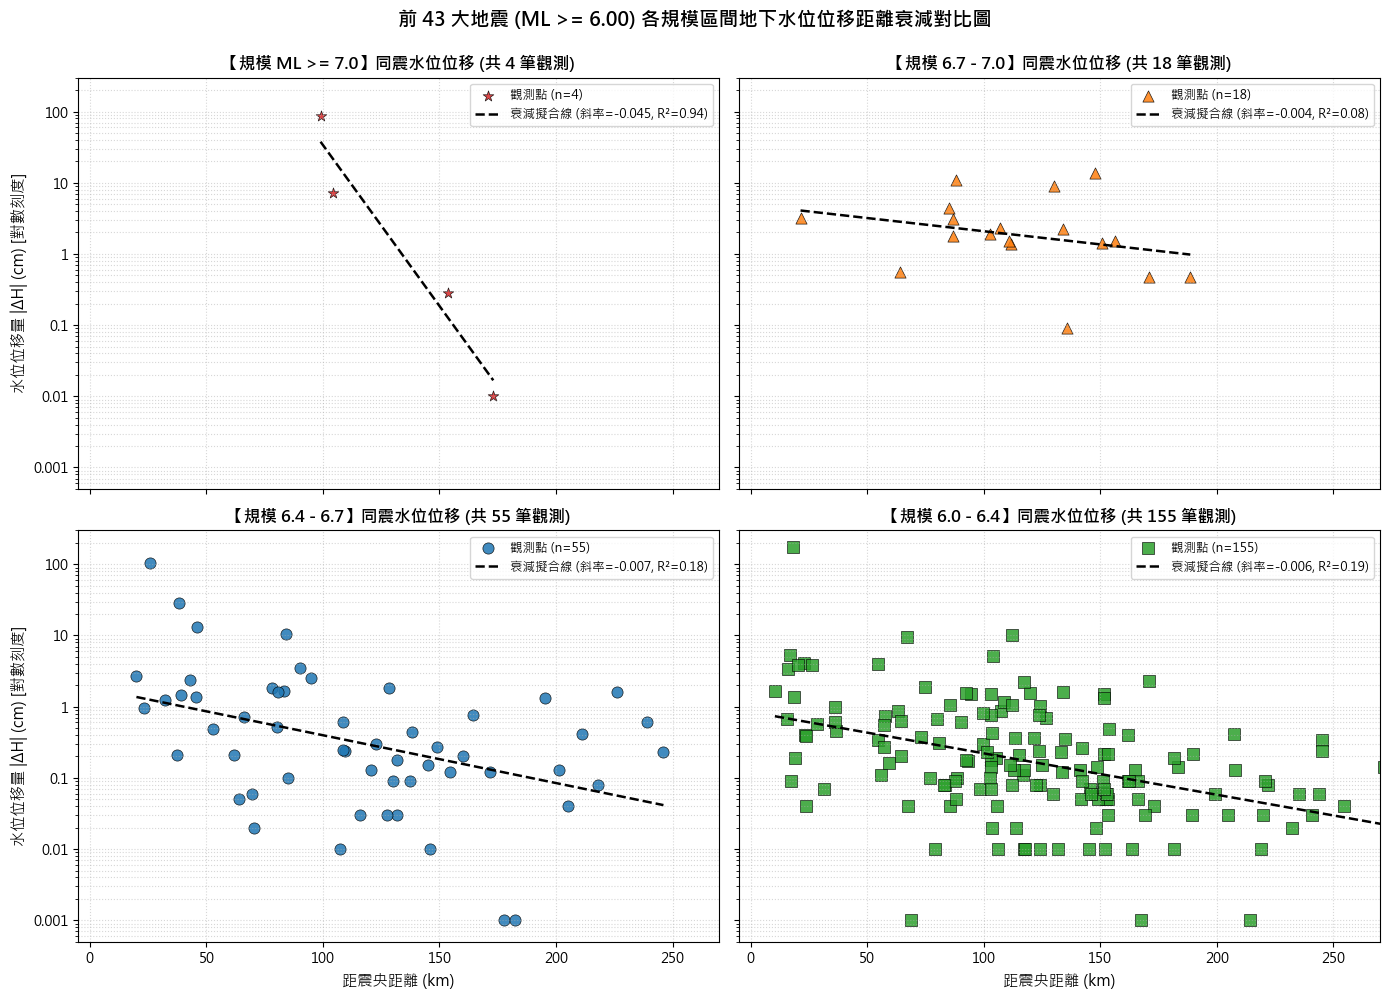

📊 共繪製 232 筆觀測點

📋 各規模區間地下水位同震位移距離衰減迴歸參數彙整表：


,規模區間,觀測點數 (N),截距 a,衰減斜率 b,判定係數 (R²),p 值 (顯著性)
0,ML >= 7.0,4,6.0521,-0.04522,0.9395,0.0307
1,6.7 - 7.0,18,0.6889,-0.00370,0.0803,0.2546
2,6.4 - 6.7,55,0.2709,-0.00672,0.1809,0.0012
3,6.0 - 6.4,155,-0.0733,-0.00582,0.1914,1.26e-08


In [10]:
# 維度一：同震淨位移 |ΔH|
df_all, df_reg_table = analyze("ttest", "water_level")

🔍 開始計算 43 場地震之【大氣壓力】ttest ...


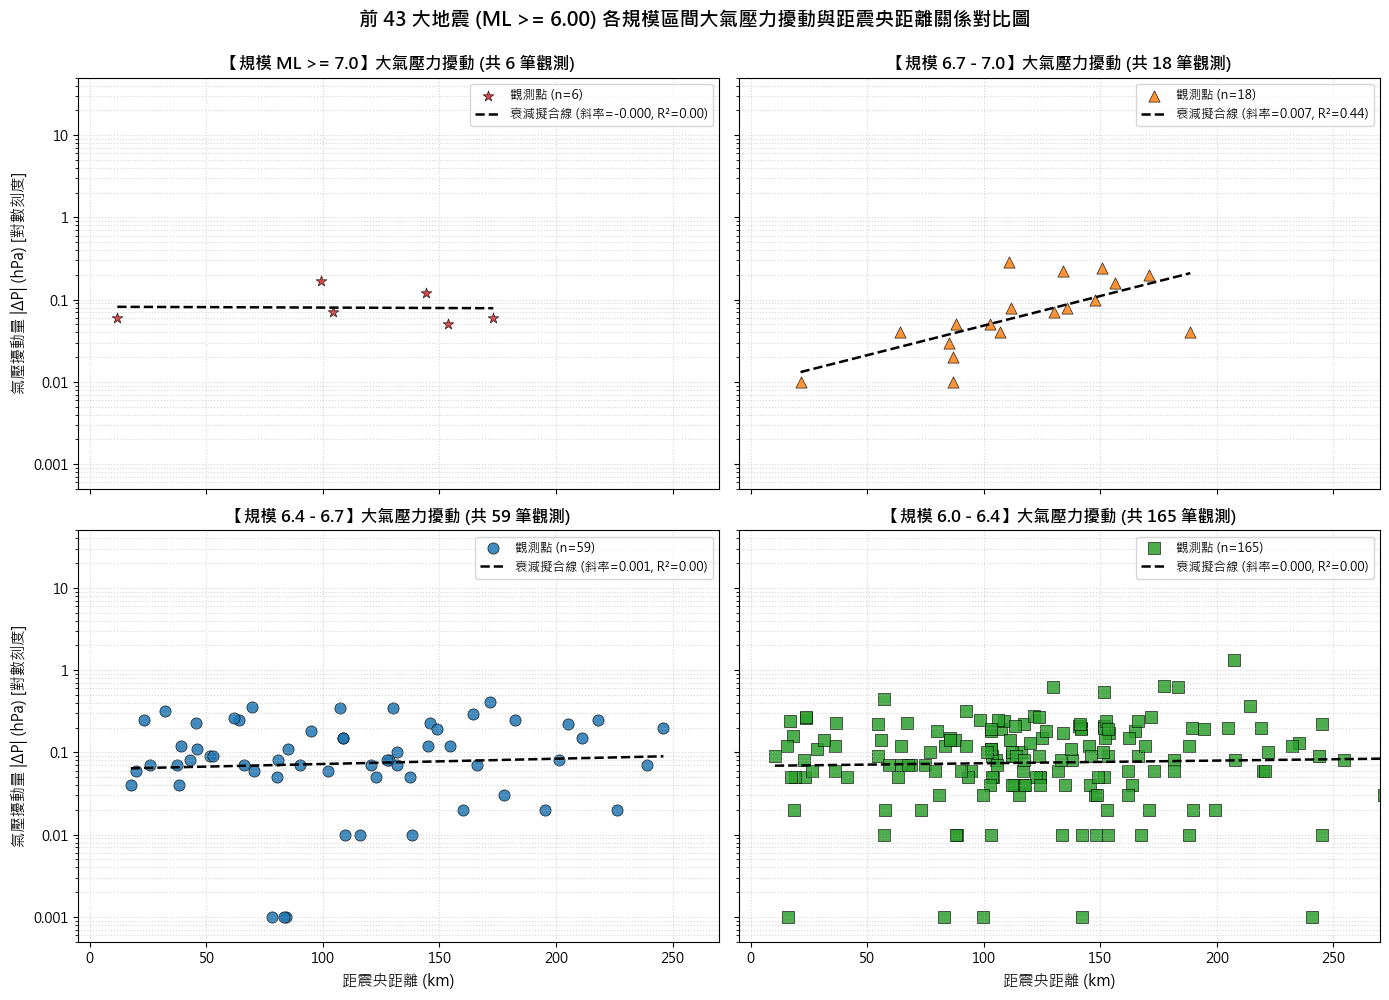

📊 共繪製 248 筆觀測點

📋 各規模區間大氣壓力同震擾動距離衰減迴歸參數彙整表：


,規模區間,觀測點數 (N),截距 a,衰減斜率 b,判定係數 (R²),p 值 (顯著性)
0,ML >= 7.0,6,-1.0862,-0.00011,0.0009,0.9554
1,6.7 - 7.0,18,-2.0349,0.00719,0.4423,0.0026
2,6.4 - 6.7,59,-1.2046,0.00064,0.0044,0.6189
3,6.0 - 6.4,165,-1.1648,0.00033,0.0013,0.6448


In [11]:
# 維度一（負對照）：大氣壓力淨位移 |ΔP|
df_all_ap, df_ap_reg_table = analyze("ttest", "pressure")

🔍 開始計算 43 場地震之【地下水位】amplitude ...


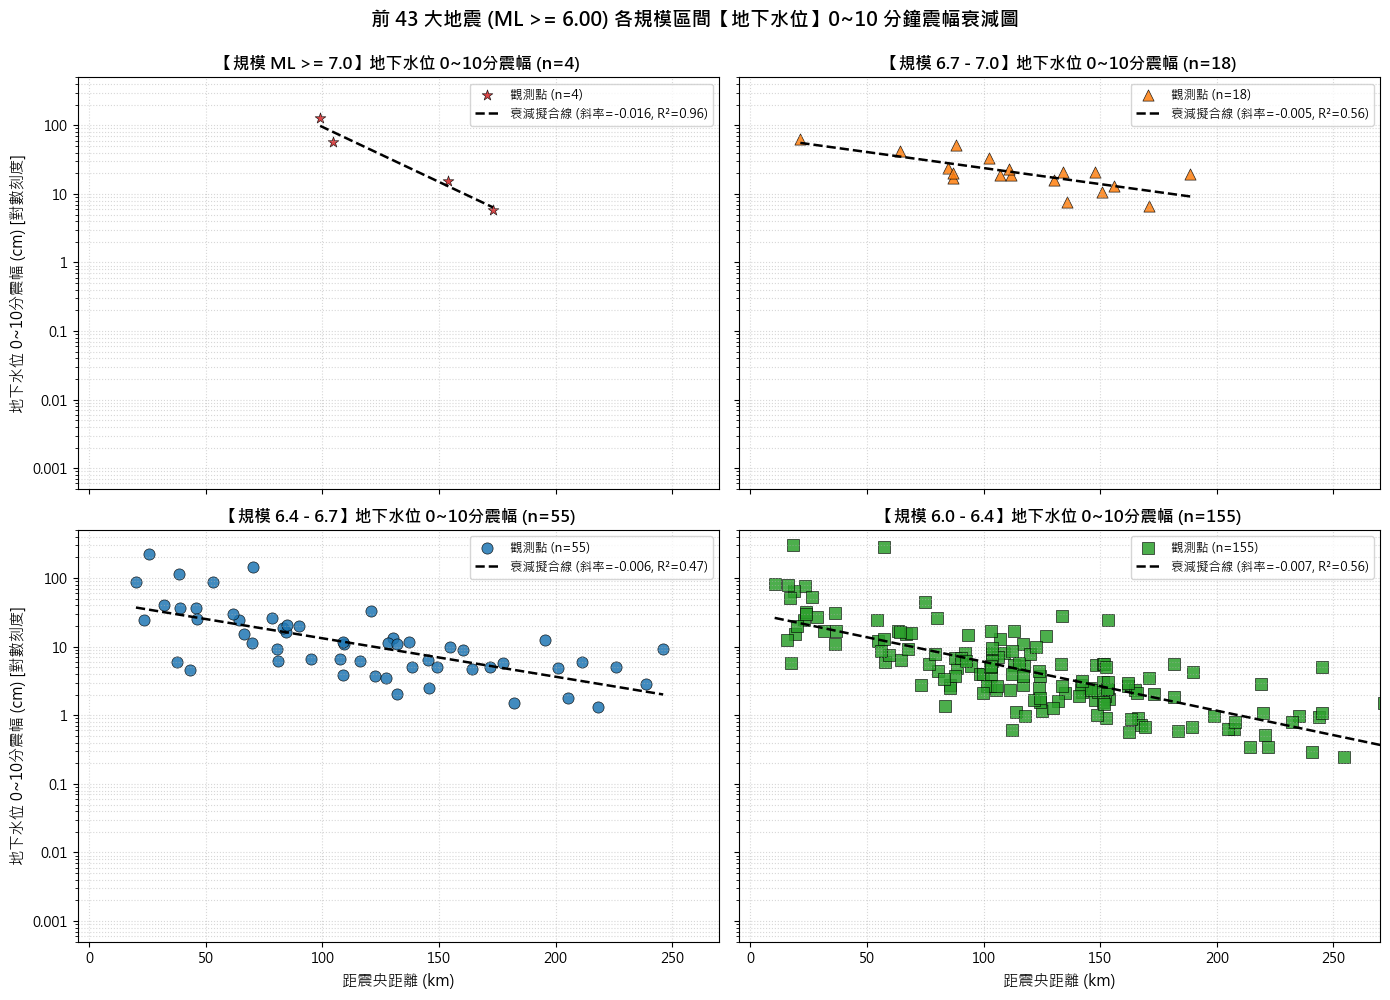

📊 共繪製 232 筆觀測點

📋 各規模區間【地下水位】0~10 分鐘震幅 (Max-Min) 距離衰減迴歸參數彙整表：


,規模區間,觀測點數 (N),截距 a,衰減斜率 b,判定係數 (R²),p 值 (顯著性)
0,ML >= 7.0,4,3.5787,-0.01603,0.9609,0.0197
1,6.7 - 7.0,18,1.8435,-0.00467,0.5550,3.89e-04
2,6.4 - 6.7,55,1.6827,-0.00561,0.4688,8.20e-09
3,6.0 - 6.4,155,1.4939,-0.00713,0.5570,7.68e-29


In [12]:
# 維度二：震後 0~10 分鐘峰對峰震幅（地下水位）
df_amp_wl, df_amp_wl_reg = analyze("amplitude", "water_level")

🔍 開始計算 43 場地震之【大氣壓力】amplitude ...


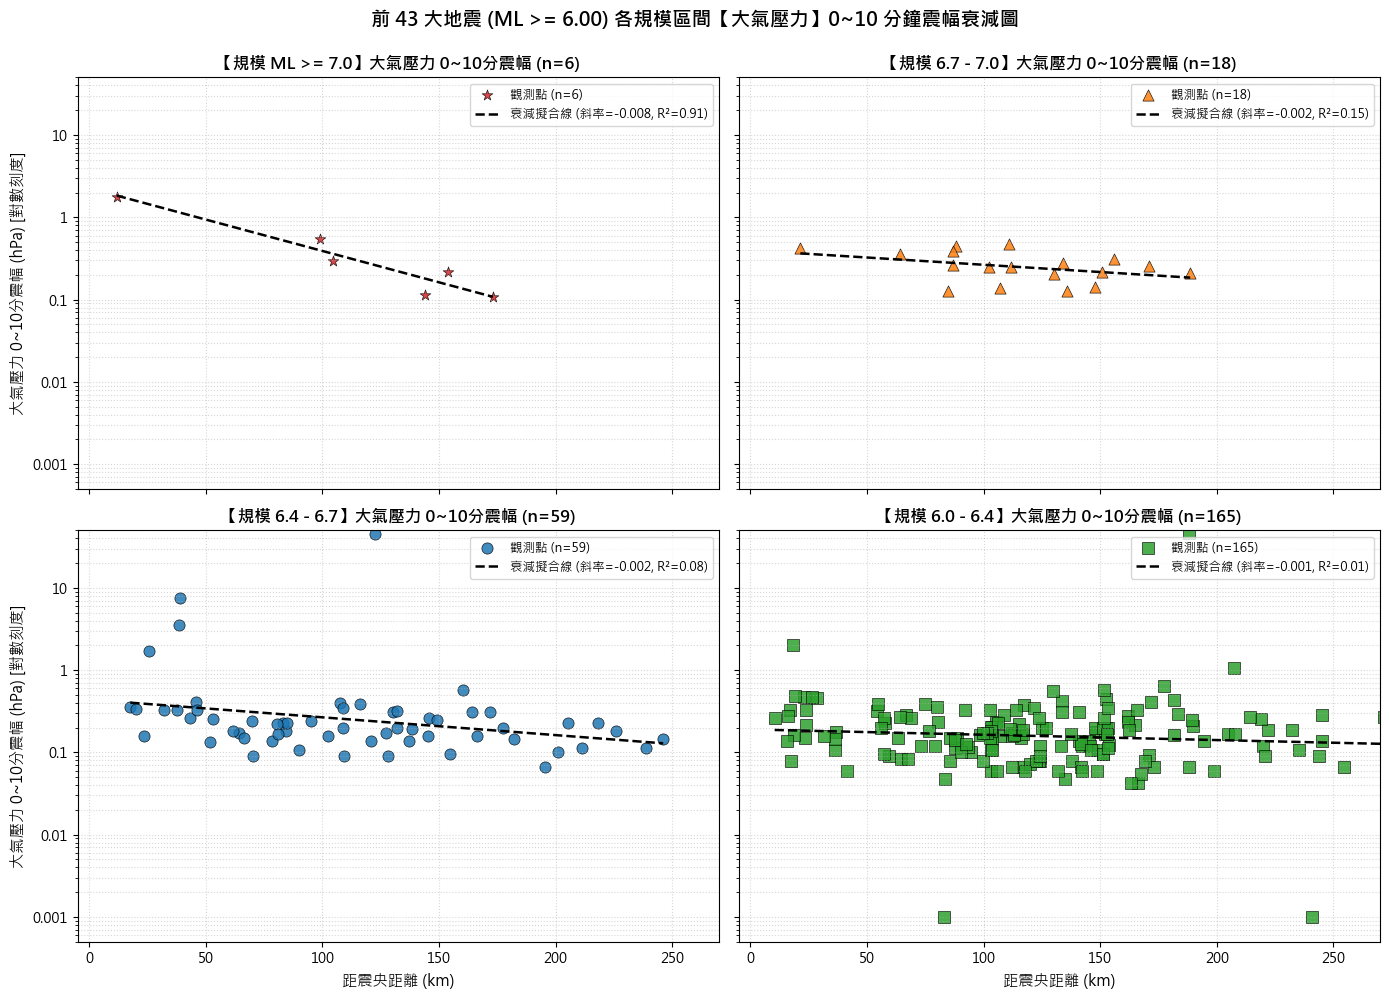

📊 共繪製 248 筆觀測點

📋 各規模區間【大氣壓力】0~10 分鐘震幅 (Max-Min) 距離衰減迴歸參數彙整表：


,規模區間,觀測點數 (N),截距 a,衰減斜率 b,判定係數 (R²),p 值 (顯著性)
0,ML >= 7.0,6,0.3531,-0.00762,0.9141,0.0029
1,6.7 - 7.0,18,-0.4009,-0.00176,0.1505,0.1116
2,6.4 - 6.7,59,-0.3580,-0.00216,0.0824,0.0275
3,6.0 - 6.4,165,-0.7213,-0.00065,0.0083,0.2446


In [13]:
# 維度二（負對照）：震後 0~10 分鐘峰對峰震幅（大氣壓力）
df_amp_ap, df_amp_ap_reg = analyze("amplitude", "pressure")